# Report on changes to the temperature calculations

## Introduction

The purpose of this notebook is to describe some issues found with the way temperatures were dealt with in the AtLAST Sensitivity Calculator and how we are correcting for them.

We begin by importing relevant modules and defining the location of the files output from the am code.

In [1]:
# Import necessary modules
import numpy as np
import matplotlib.pyplot as pl
from astropy import units as u
import astropy.constants as const

# Directory for the location of the am output
amfilesdir = 'am_files/'

## Sensitivity calculator version 1

In version 1 of the calculator, the system temperature was defined as

$$    T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) T_{amb}]$$

where 
* $\eta_{eff}$ is the forward efficiency of the telescope
* $\mathfrak{t}$ is the atmospheric transmittance
* $T_{rx}$ is the receiver temperature
* $T_{sky}$ is the sky temperature
* $T_{amb}$ is the ambient temperature

The receiver temperature was calculated as

$$ T_{rx} = \frac{5h\nu}{k} $$

where
* $h$ is Planck's constant
* $\nu$ is the observing frequency
* $k$ is Boltzmann's constant

The sky temperature was calculated as

$$    T_{sky} = (1- \mathfrak{t}) T_{atm} + T_{cmb}$$

where
* $ T_{atm}$ is the atmospheric temperature
* $  T_{cmb}$ is the cosmic microwave background temperature

To calculate the atmospheric temperature we make use of the am code. We make use of the provided configuration file for ACT, which is close to the potential sites for AtLAST, and modify it to output just the thermodynamic brightness temperature, $T_{b}$ (which was interpreted as $T_{sky}(z=0)$), and opacity, $\tau_0$ at zenith. 

Following [ALMA memo 602](https://library.nrao.edu/public/memos/alma/main/memo602.pdf), we calculated $T_{sky}$ at the desired zenith angle, $z$, (90 degrees minus the elevation) by setting 

$$ T_{atm} = \frac{T_{sky}(z=0)}{1-e^{-\tau_0}} $$
$$ \mathfrak{t} = e^{-\tau_0\sec{z}} $$

In the following we assume for our example a 25% water column. The am output is then created using the command: 

am ACT_annual_25_inc_Tcmb.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt


/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


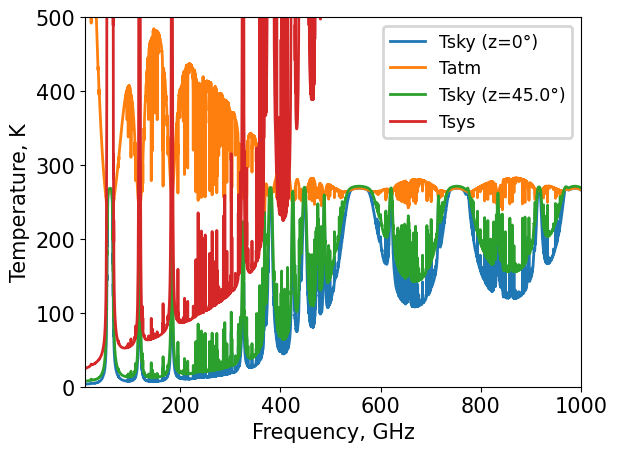

In [51]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt'

# Telescope constants
eta_eff = 0.95
tamb = 270*u.K
tcmb = 2.726*u.K

# User parameter
elevation = 45*u.deg

# Read in file
fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K  # T_sky at zenith from the am file output
tau0 = fileimp[:,1] # opacity at zenith

tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + tcmb # Tsky at chosen elevation

trx = 5*const.h*freqs/const.k_B # receiver temperature
tsys_1 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')  
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')   
pl.plot(freqs, tsys_1, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)




/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


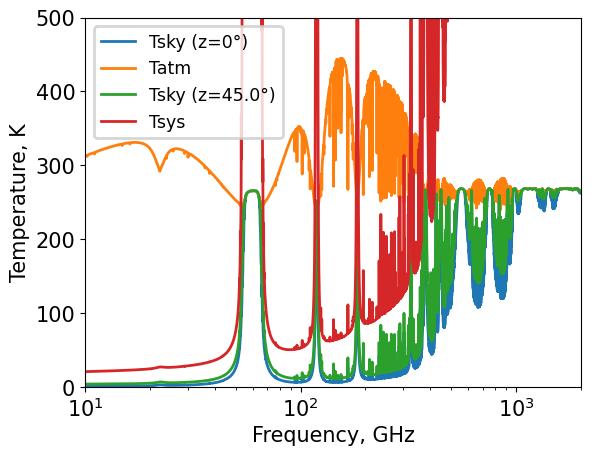

In [ ]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25.txt'

fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K
tau0 = fileimp[:,1]
tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb

tsys = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


(10, 2000)

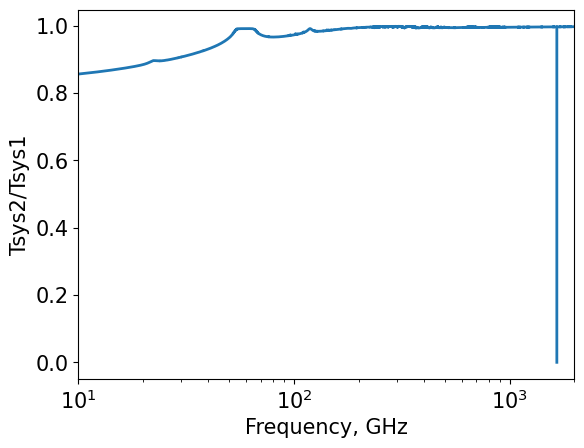

In [ ]:
pl.figure()
pl.plot(freqs, tsys/tsys_cmb)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys2/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)

/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


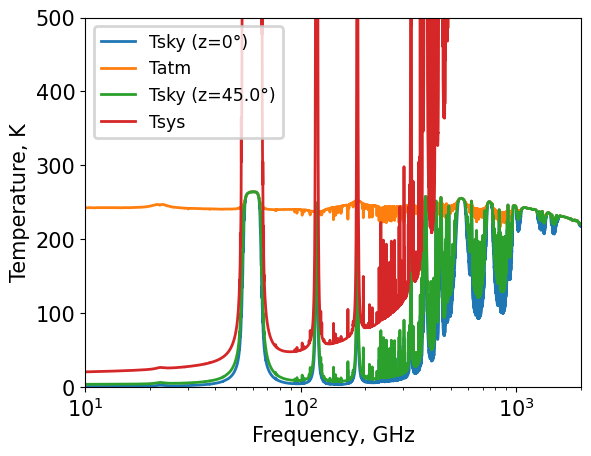

In [ ]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_trj.txt'

fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K
tau0 = fileimp[:,1]
tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb

tsys_rj1 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_rj1, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(10, 2000)

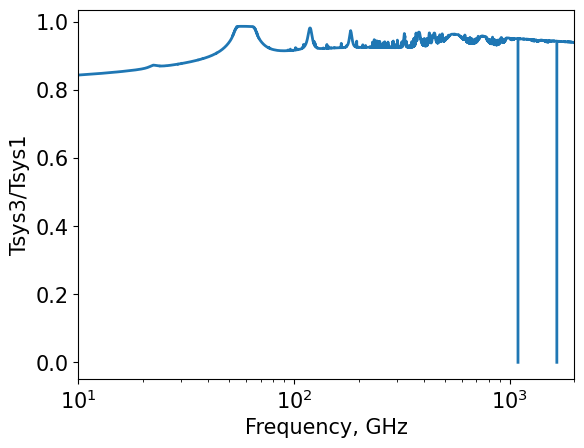

In [ ]:
pl.figure()
pl.plot(freqs, tsys_rj1/tsys_cmb)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys3/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)

In [29]:
def noise_temperature(temperature, frequency):
    """
    Function to convert a thermodynamic temperature to a Rayleigh-Jeans brightness temperature.
    See e.g. equation 7.5 from Interferometry and Synthesis in Radio Astronomy.
    Temperature and frequency will need to have astropy units. 
    """
    ratio = (const.h*frequency)/(const.k_B*temperature)
    noise_temp = temperature*(ratio/np.expm1(ratio))
    return noise_temp

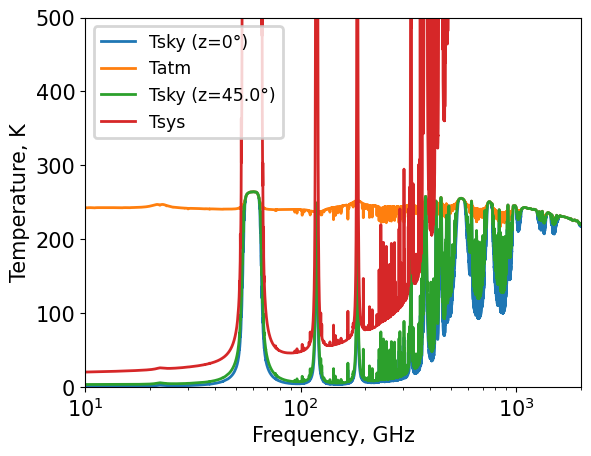

In [ ]:
tskyznon0 = tatm * (1-transmittance) + transmittance * noise_temperature(tcmb, freqs)

tsys_rj2 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*noise_temperature(tamb, freqs))).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_rj2, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)

/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(10, 2000)

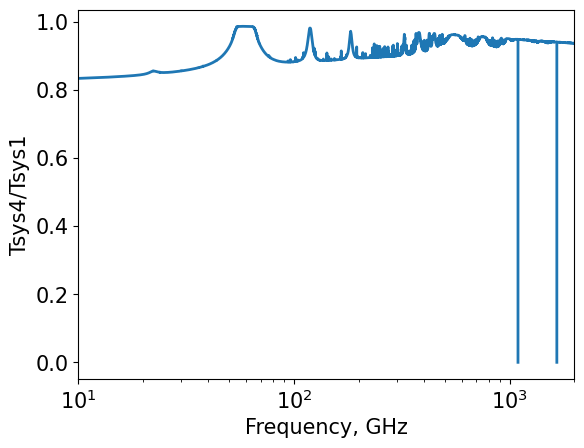

In [ ]:
pl.figure()
pl.plot(freqs, tsys_rj2/tsys_cmb)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys4/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)